Lab 1: Document Processing with OCR

In this lesson, you will build an agent for document processing with optical character recognition (OCR).

Learning Objectives:

    Parsing and extracting information from documents
    Building an agent equipped with an OCR tool
    Identifying failure modes of OCR

Background

Document processing converts unstructured documents meant for humans into structured data meant for machines. When documents are scanned images, OCR converts pixels to text. However, OCR alone produces raw text. Using LLMs, we can make sense of it. 

### 1- Make imports

In [1]:
from PIL import Image

import pytesseract

from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor

from langchain_openai import ChatOpenAI

### 2- Create OCR tool

In [17]:
from langchain.tools import tool

@tool
def ocr_read_doc(image_path: str) -> str:
    """Reads text from an image document using OCR."""
    try:
        text = pytesseract.image_to_string(Image.open(image_path))
        return text
    except Exception as e:
        return f"Error reading document: {e}"

#### 2.1- Use OCR to parse a sample document

In [5]:
doc_path = 'files/TD_CASH_BACK_VISA_INFINITE__CARD_3226_Feb_06-2026.pdf'

In [12]:
# turn PDF pages into images
import fitz
from PIL import Image

doc = fitz.open(doc_path)
for i, page in enumerate(doc):
    pix = page.get_pixmap()
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    img.save(f"files/page_{i}.png")

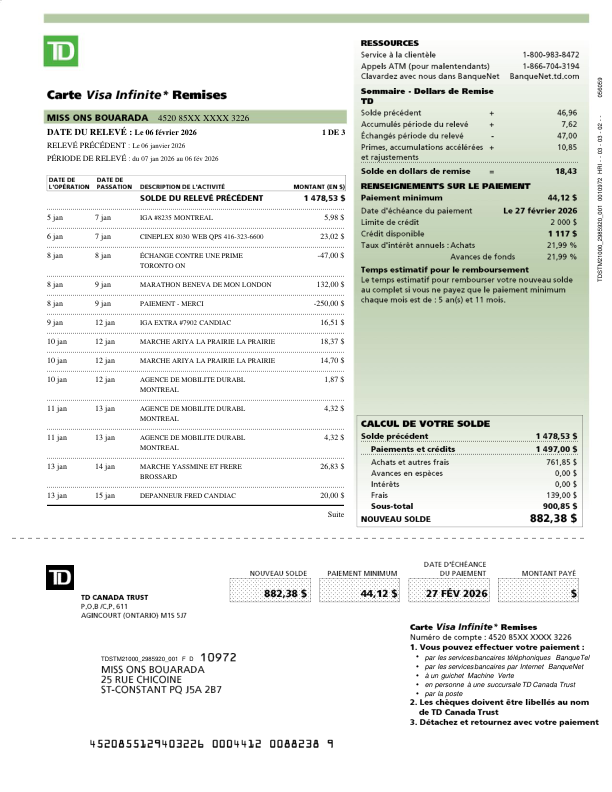

In [13]:
from IPython.display import display

image_path = 'files/page_0.png'
img = Image.open(image_path)
display(img)

In [8]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

In [19]:
ocr_text = ocr_read_doc.run("files/invoice_sample.png")

print("raw OCR output:\n ---------------------\n", ocr_text)


raw OCR output:
 ---------------------
 Your Company Inc.

1234 Company St,
Company Town, ST 12345

Bill To
Customer Name

1234 Customer St,
Customer Town, ST 12345

@& Upload Logo

INVOICE

Invoice # 0000007
Invoice date 10-02-2023
Due date 10-16-2023

Amount

1.00 Replacement of spark plugs 40.00 $40.00
2.00 Brake pad replacement (front) 40.00 $80.00
4.00 Wheel alignment 17.50 $70.00
2.00 Mechanic's rate per hour 30.00 $60.00
Subtotal $250.00

Sales Tax (5%) $12.50

Total (USD) $262.50

Terms and Conditions
Payment is due in 14 days

Please make checks payable to: Your Company Inc.




#### 2.2. Use Regex to Extract Information

In [21]:
import re
tax_match = re.search(r'Sales Tax\s*\$?([0-9.,]+)', ocr_text)
total_match = re.search(r'Total\s*\$?([0-9.,]+)', ocr_text)

if tax_match:
    print("tax: ", tax_match.group(1))
else:
    print("no match was found")

if total_match:
    print("total: ", total_match.group(1))
else:
    print("no match was found")

no match was found
no match was found


In [24]:
import re

pattern = re.compile(
    r"(?i)\bSales\s*Tax\b\s*[:\-]?\s*([$€]?\s*\d+[.,]\d{2})"
)

match = pattern.search(ocr_text)
tax_value = match.group(1) if match else None
tax_value

In [23]:
ocr_text

"Your Company Inc.\n\n1234 Company St,\nCompany Town, ST 12345\n\nBill To\nCustomer Name\n\n1234 Customer St,\nCustomer Town, ST 12345\n\n@& Upload Logo\n\nINVOICE\n\nInvoice # 0000007\nInvoice date 10-02-2023\nDue date 10-16-2023\n\nAmount\n\n1.00 Replacement of spark plugs 40.00 $40.00\n2.00 Brake pad replacement (front) 40.00 $80.00\n4.00 Wheel alignment 17.50 $70.00\n2.00 Mechanic's rate per hour 30.00 $60.00\nSubtotal $250.00\n\nSales Tax (5%) $12.50\n\nTotal (USD) $262.50\n\nTerms and Conditions\nPayment is due in 14 days\n\nPlease make checks payable to: Your Company Inc.\n\n"

### 3- Create the agent

In [26]:
import os
from dotenv import load_dotenv

_ = load_dotenv(override=True)

In [ ]:
# define the tools

tools = [ocr_read_doc]

# set up the OpenAI model
from langchain_openai import ChatOpenAI
